In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from inputs_for_plots import *

In [2]:
def plot_error_distribution(df, ax=None,i =0, cl = None):
    err, _ = calc_error(df)
    err = err.apply(lambda x: np.abs(x))
    err.columns = cl
    long = err.melt(var_name="variable", value_name="value")

    # Get color palette
    palette = sns.color_palette(n_colors=err.shape[1])
    
    # Create the violin plot
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 5))  # Erstelle nur eine neue Figur, wenn ax nicht übergeben wurde
    
    sns.boxplot(data=long, hue="variable", y="value", palette=palette, ax=ax)

    # Draw the reference line
    ax.axhline(y=0, c="red", linestyle="--")
    ax.set_ylabel("Absolut deviation from true treatment effect",fontsize=20 )
    ylims = [(0,4), (0,6), (0,9)]
    ax.set_ylim(ylims[i])
    # Compute mean and standard deviation
    rmse = err.apply(lambda x: np.sqrt(np.mean(x**2)))
    mae = err.apply(lambda x: np.mean(x))
    std = err.apply(lambda x: np.std(x))

    # Create legend patches
    max_col_length = max(len(col) for col in err.columns)

    handles = [
        mpatches.Patch(
            color=palette[i],
            label=f"RMSE = {rmse[col]:2.2f}, MAE = {mae[col]:2.2f}, Std = {std[col]:2.2f}  : {col}"
        )
        for i, col in enumerate(err.columns)
    ]



    
    ax.legend(handles=handles, loc="upper right", fontsize=22)
    return ax



# Plot increase in confounding

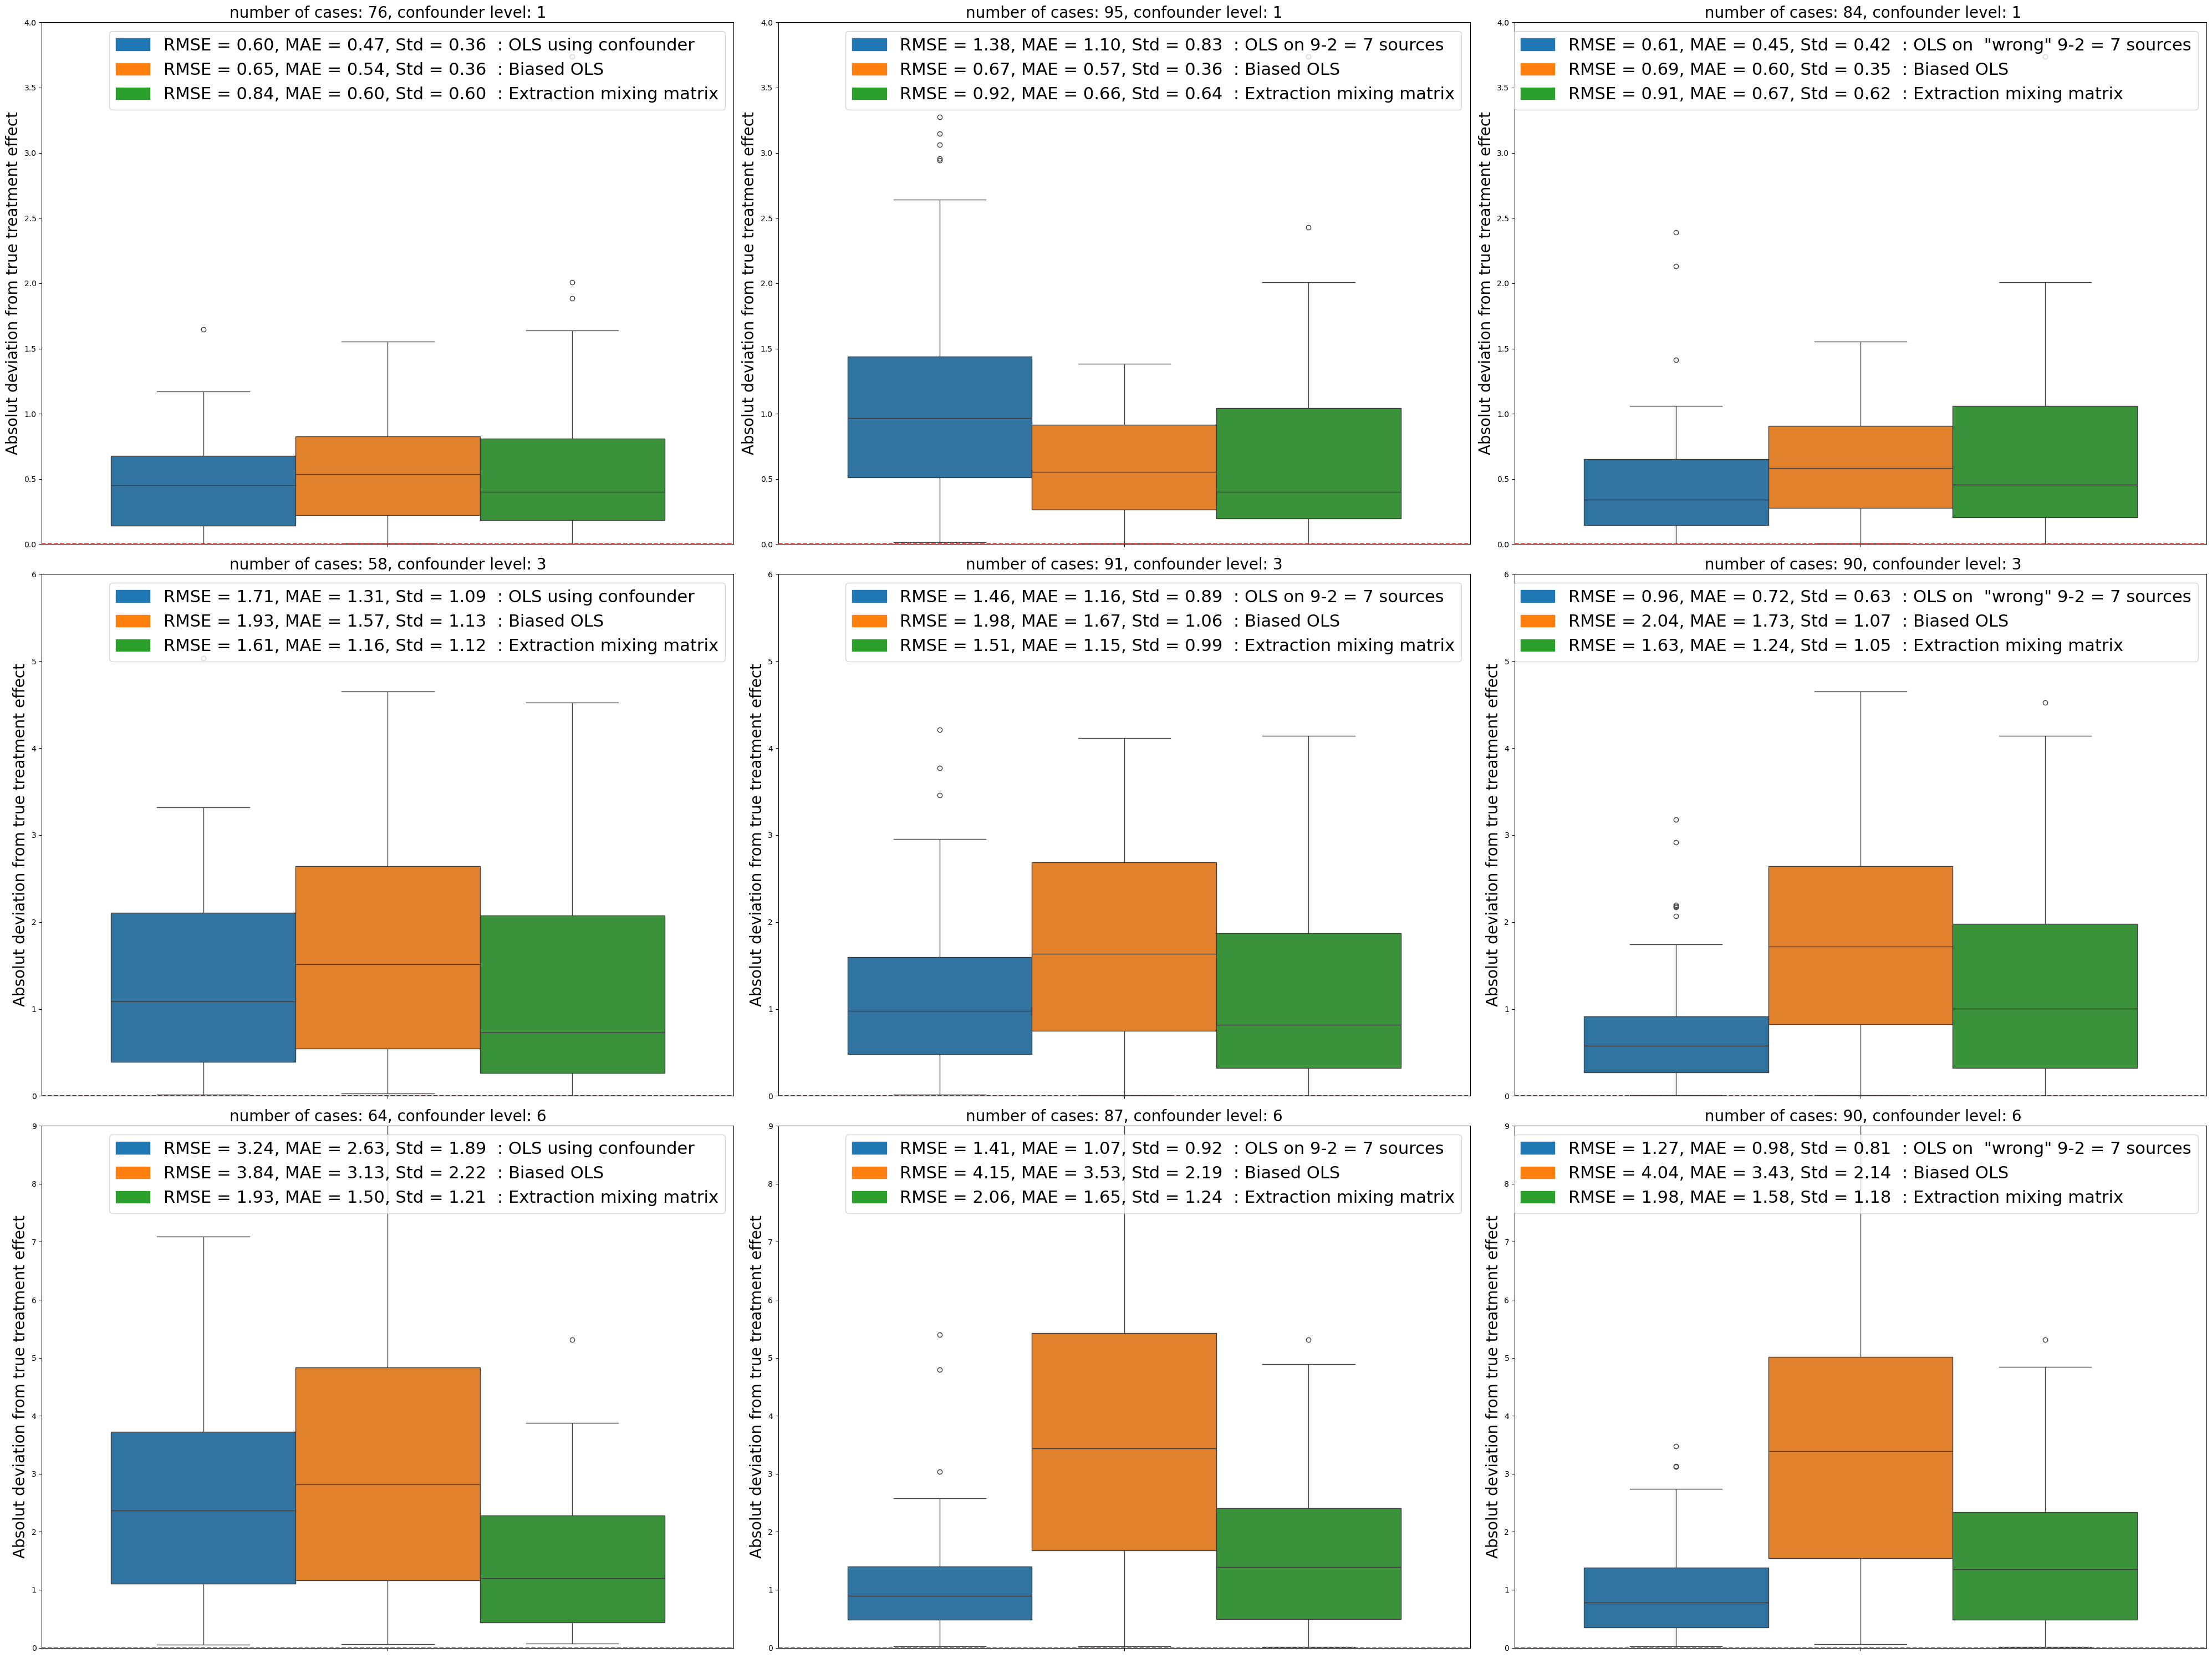

In [3]:
# Define subplot layout
fig, ax = plt.subplots(3, 3, figsize=(40, 30))
confounder_levels = [1, 3, 6]

for i, level in enumerate(confounder_levels):
    data1 = pd.read_csv(f"../treatment_effect_estimation/treatment_effect_estimations/CausalVarEM_confounder_source_cn_{level}.csv", header=0, index_col=0)
    cl = ["OLS using confounder", "Biased OLS" ,"Extraction mixing matrix"]
    plot_error_distribution(data1, ax[i, 0], i ,cl)
    ax[i, 0].set_title(f"number of cases: {data1.shape[0]}, confounder level: {level}", fontsize=20)

    data2 = pd.read_csv(f"../treatment_effect_estimation/treatment_effect_estimations/CausalVarEM_7_sources_cn_{level}.csv", header=0, index_col=0)
    cl = ["OLS on 9-2 = 7 sources", "Biased OLS" ,"Extraction mixing matrix"]
    plot_error_distribution(data2, ax[i, 1], i,cl)
    ax[i, 1].set_title(f"number of cases: {data2.shape[0]}, confounder level: {level}", fontsize=20)

    data3 = pd.read_csv(f"../treatment_effect_estimation/treatment_effect_estimations/CausalVarEM_7_sources_nonsense_cn_{level}.csv", header=0, index_col=0)
    cl = ["OLS on  \"wrong\" 9-2 = 7 sources", "Biased OLS" ,"Extraction mixing matrix"]
    plot_error_distribution(data3, ax[i, 2], i, cl)
    ax[i, 2].set_title(f" number of cases: {data3.shape[0]}, confounder level: {level}",fontsize=20)
plt.subplots_adjust(wspace=-0.2, hspace=0.3)
plt.tight_layout()
plt.show()


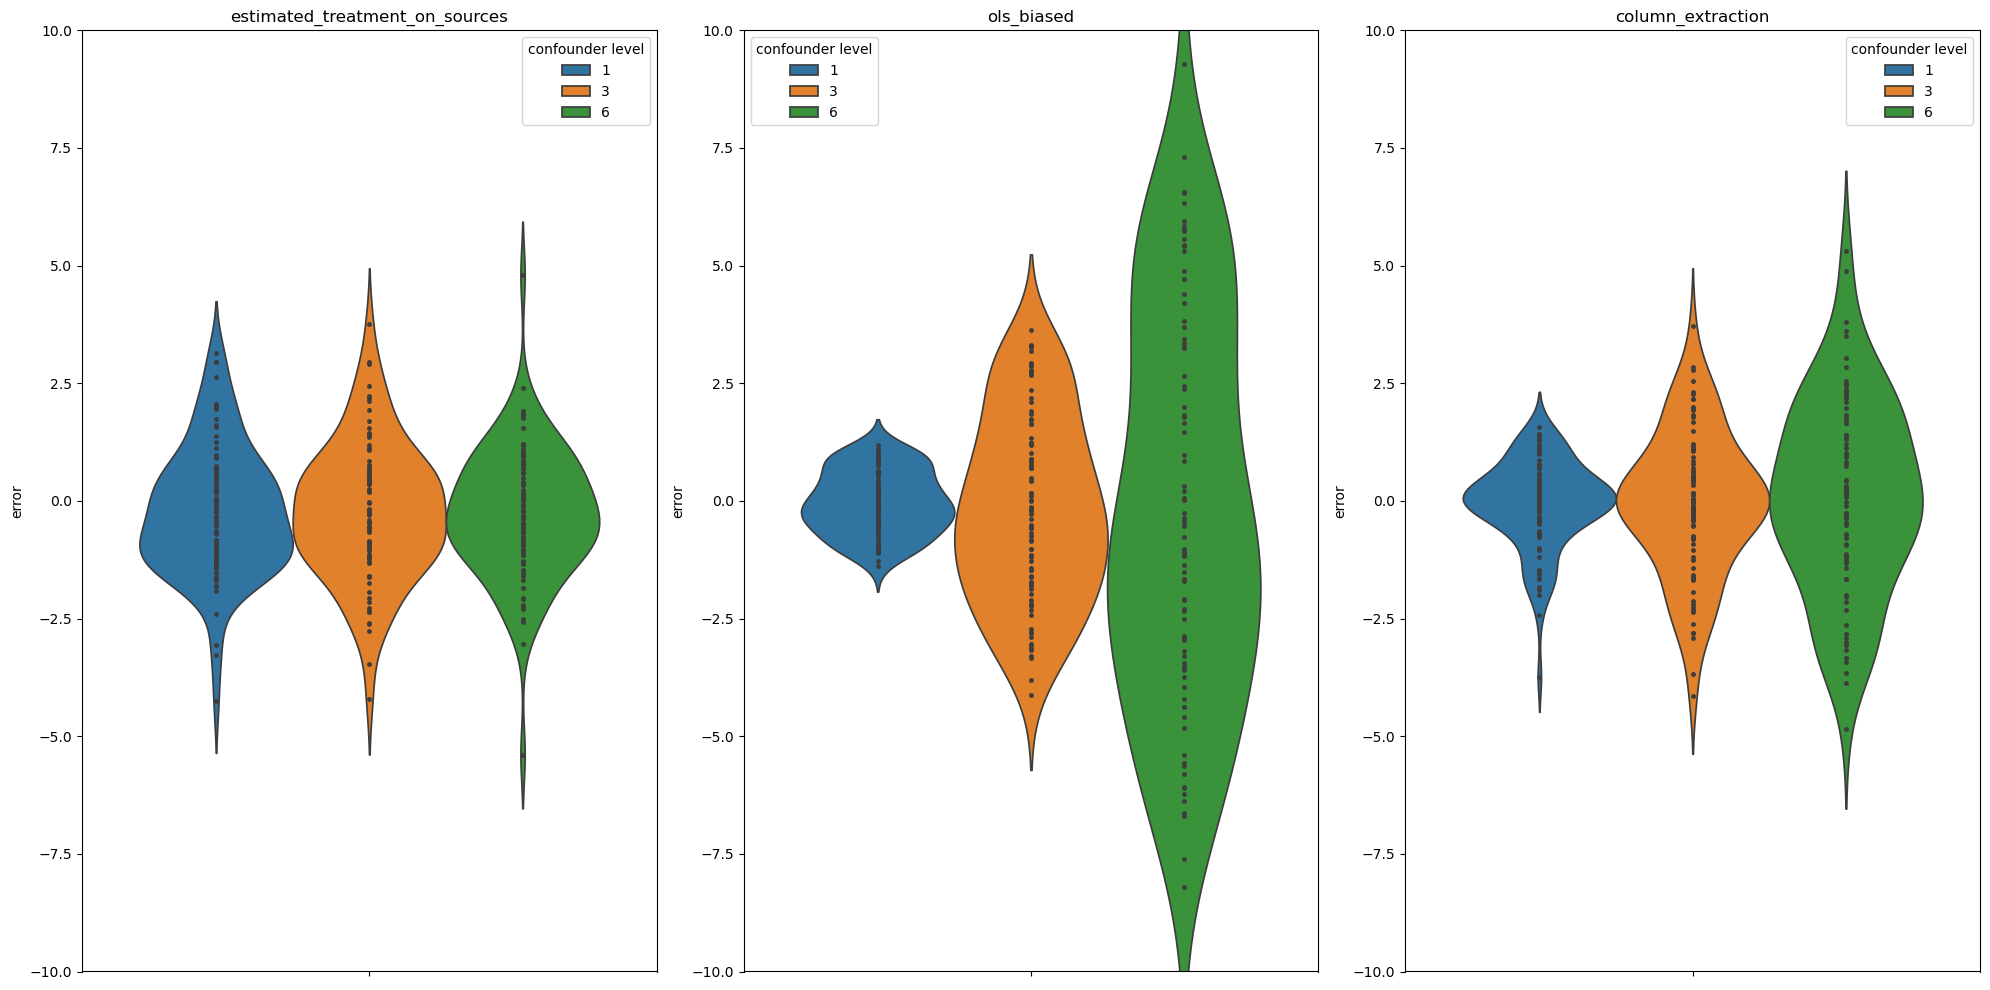

In [4]:
# plot different confounding levels in one plot one for each method
data1 = pd.read_csv(f"../treatment_effect_estimation/treatment_effect_estimations/CausalVarEM_7_sources_cn_{1}.csv", header=0, index_col=0)
err1, seed = calc_error(data1)
data3 = pd.read_csv(f"../treatment_effect_estimation/treatment_effect_estimations/CausalVarEM_7_sources_cn_{3}.csv", header=0, index_col=0)
err3 = calc_error(data3)[0]
data6 = pd.read_csv(f"../treatment_effect_estimation/treatment_effect_estimations/CausalVarEM_7_sources_cn_{6}.csv", header=0, index_col=0)
err6 = calc_error(data6)[0]

methods = err1.columns
fig, ax = plt.subplots(1, 3, figsize=(20, 10))
for method in methods:
    df = pd.DataFrame({"1": err1[method], "3": err3[method], "6": err6[method]})
    long = df.melt(var_name="confounder level", value_name="error")
    sns.violinplot(data=long, hue="confounder level", y="error", ax=ax[methods.get_loc(method)], inner="point")

    ax[methods.get_loc(method)].set_title(method)
    ax[methods.get_loc(method)].set_ylim(-10, 10)
plt.tight_layout()
plt.show()


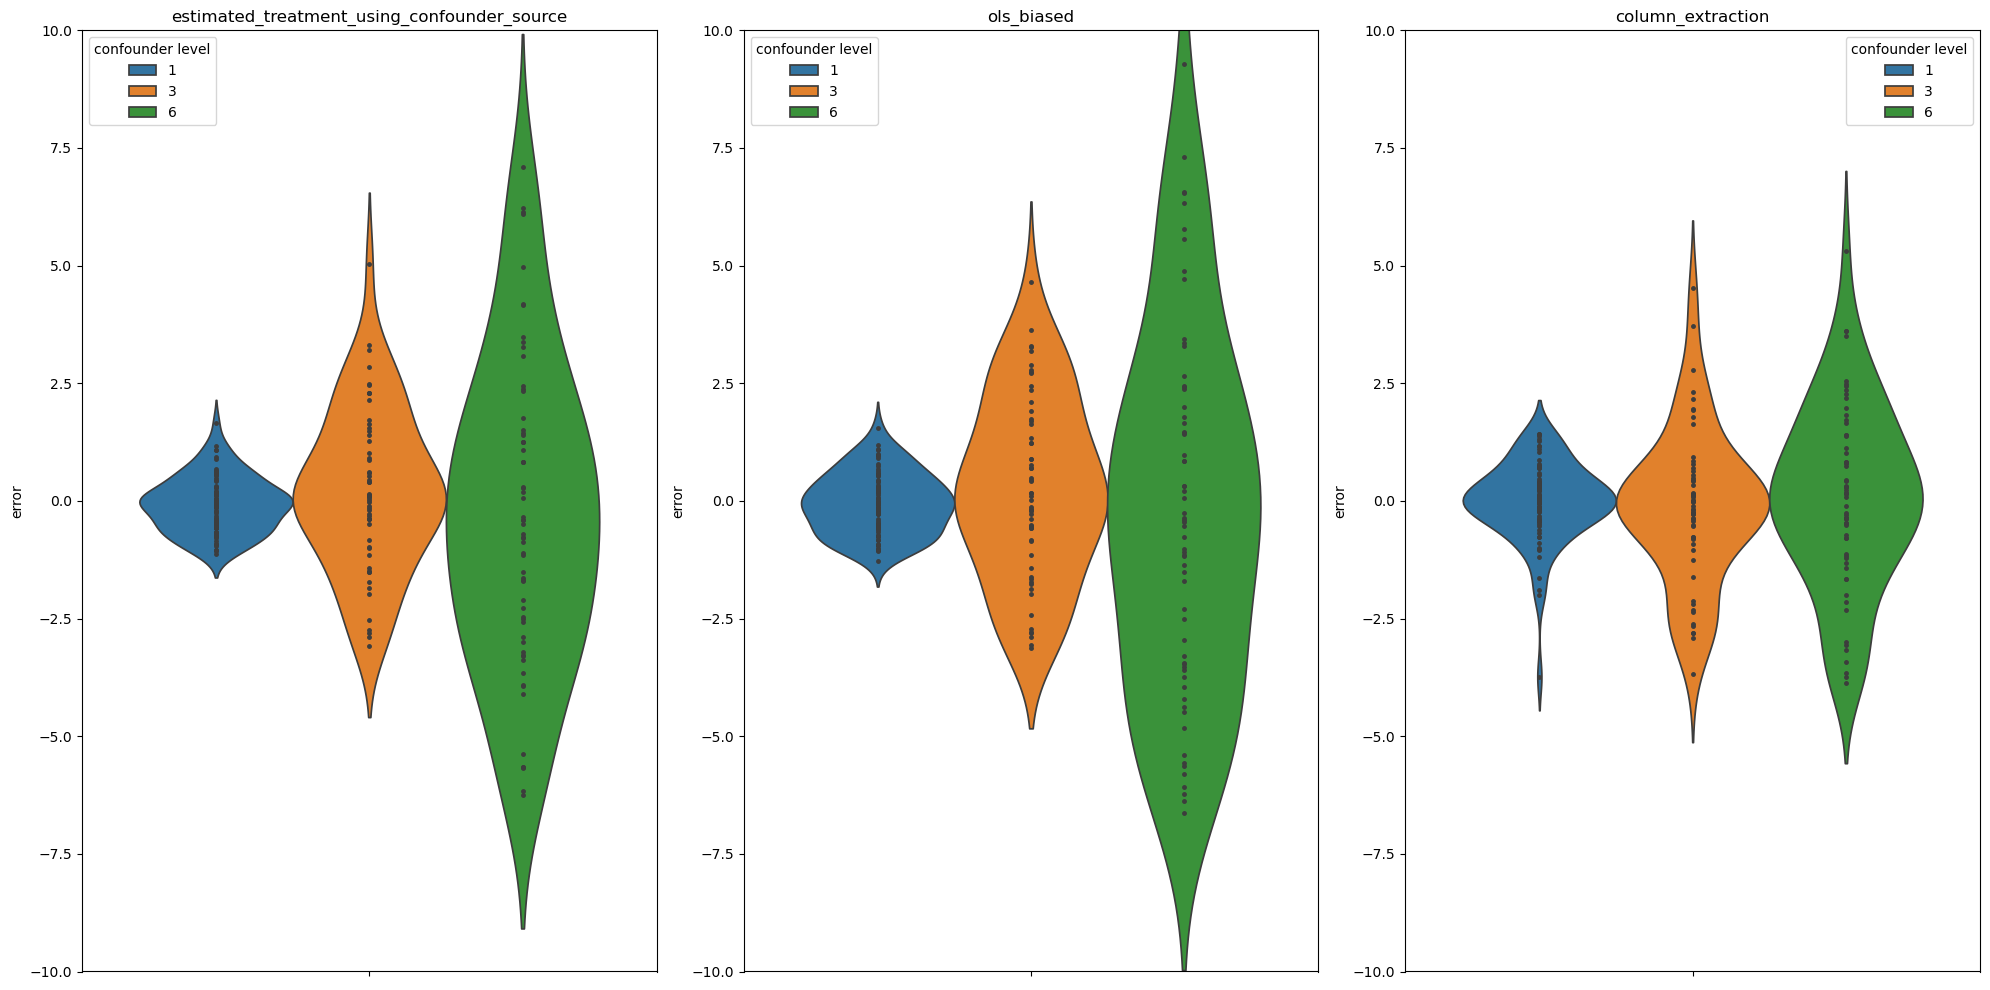

In [5]:
data1 = pd.read_csv(f"../treatment_effect_estimation/treatment_effect_estimations/CausalVarEM_confounder_source_cn_{1}.csv", header=0, index_col=0)
err1, seed = calc_error(data1)
data3 = pd.read_csv(f"../treatment_effect_estimation/treatment_effect_estimations/CausalVarEM_confounder_source_cn_{3}.csv", header=0, index_col=0)
err3 = calc_error(data3)[0]
data6 = pd.read_csv(f"../treatment_effect_estimation/treatment_effect_estimations/CausalVarEM_confounder_source_cn_{6}.csv", header=0, index_col=0)
err6 = calc_error(data6)[0]

methods = err1.columns
fig, ax = plt.subplots(1, 3, figsize=(20, 10))
for method in methods:
    df = pd.DataFrame({"1": err1[method], "3": err3[method], "6": err6[method]})
    long = df.melt(var_name="confounder level", value_name="error")
    sns.violinplot(data=long, hue="confounder level", y="error", ax=ax[methods.get_loc(method)], inner="point")
    ax[methods.get_loc(method)].set_ylim(-10, 10)

    ax[methods.get_loc(method)].set_title(method)
plt.tight_layout()
plt.show()


# Plot bounded treatment

In [10]:
data1 = pd.read_csv("../treatment_effect_estimation/treatment_effect_estimations/CausalVarEM_confounder_source_bounded_treatment.csv", header=0, index_col=0)
data2 = pd.read_csv("../treatment_effect_estimation/treatment_effect_estimations/CausalVarEM_7_sources_bounded_treatment.csv", header=0, index_col=0)
data3 = pd.read_csv("../treatment_effect_estimation/treatment_effect_estimations/CausalVarEM_7_sources_nonsense_bounded_treatment.csv", header=0, index_col=0)

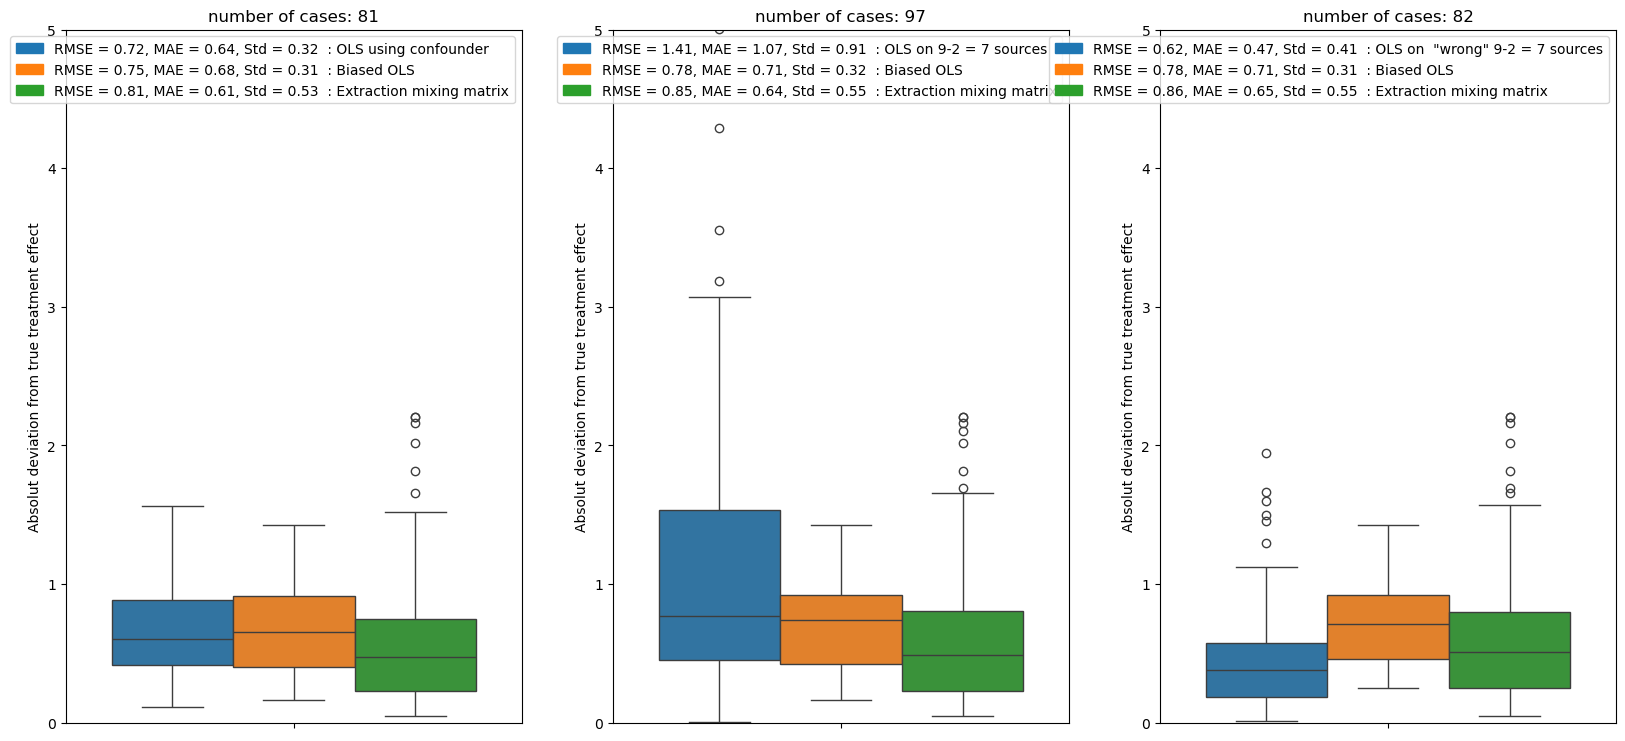

In [20]:
fig, ax = plt.subplots(1, 3, figsize=(20,9))
err1, seed = calc_error(data1)
err1.columns = ["OLS using confounder", "Biased OLS" ,"Extraction mixing matrix"]
err2, seed = calc_error(data2)
err2.columns = ["OLS on 9-2 = 7 sources", "Biased OLS" ,"Extraction mixing matrix"]
err3, seed = calc_error(data3)
err3.columns = ["OLS on  \"wrong\" 9-2 = 7 sources", "Biased OLS" ,"Extraction mixing matrix"]
err = [err1, err2, err3]
for i in range(3):
    err_ = err[i].apply(lambda x: np.abs(x))
    
    rmse = err_.apply(lambda x: np.sqrt(np.mean(x**2)))
    mae = err_.apply(lambda x: np.mean(x))
    std = err_.apply(lambda x: np.std(x))
    df_long = err_.melt(var_name="variable", value_name="value")
    sns.boxplot(data=df_long, hue="variable", y="value", ax=ax[i])
    ax[i].set_ylabel("Absolut deviation from true treatment effect")
    ax[i].set_ylim(0, 5)

    handles = [
        mpatches.Patch(
            color=sns.color_palette()[i],
            label=f"RMSE = {rmse[col]:2.2f}, MAE = {mae[col]:2.2f}, Std = {std[col]:2.2f}  : {col}"
        )
        for i, col in enumerate(err_.columns)
    ]
    ax[i].legend(handles=handles, loc="upper right")
    ax[i].set_title(f"number of cases: {err[i].shape[0]}")

    



# plot distributions with respect to conditioning number

In [ ]:

data = pd.read_csv("../treatment_effect_estimation/treatment_effect_estimations/CausalVarEM_confounder_source_bounded_treatment.csv", header = 0, index_col=0)
cond_number = calculate_conditioning_number("../data_generation/bounded_treatment_effect/data/true_mixing_init_flipp")

#data = pd.read_csv("../treatment_effect_estimation/treatment_effect_estimations/CausalVarEM_confounder_source_cn_6.csv", header = 0, index_col=0)
#cond_number = calculate_conditioning_number("../data_generation/different_confounding_levels/data/true_mixing_large_conf_6")



cond_df = pd.DataFrame({"seed" : [i for i in range(100)], "conditioning_number" : cond_number})

In [ ]:
err, seed = calc_error(data)
df = pd.concat([err, seed], axis=1)

In [ ]:
df = pd.merge(df, cond_df, on="seed").drop("seed", axis=1)
df.shape

(81, 4)

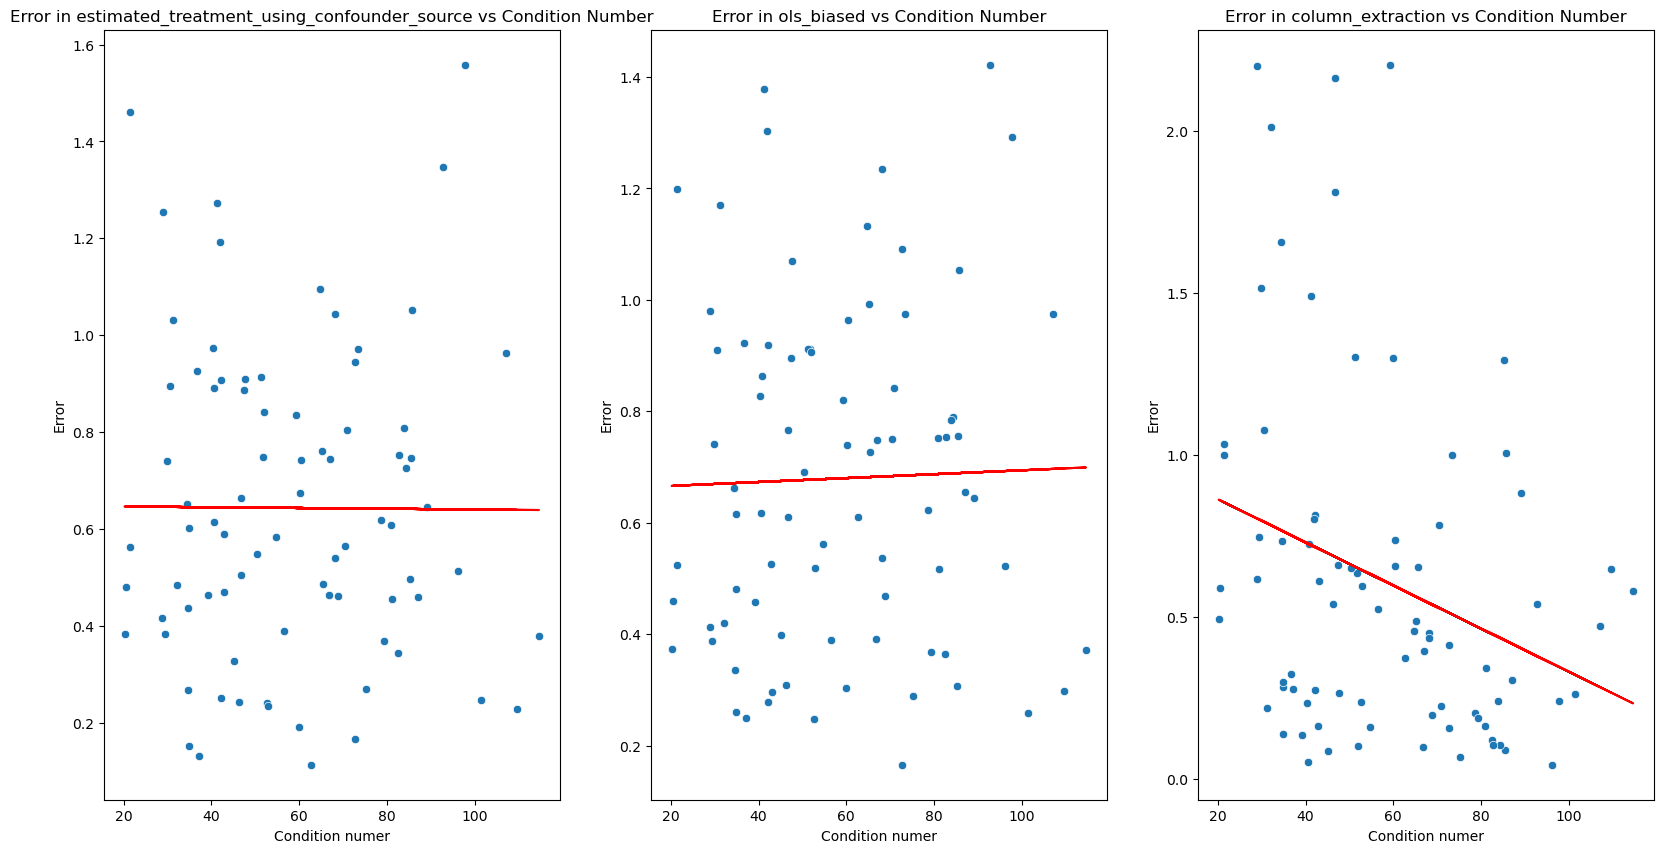

In [ ]:
fig, ax= plt.subplots(1,3, figsize=(20, 10))
cond = df["conditioning_number"]
for i in range(3):
    sns.scatterplot(x=cond, y = np.abs(df.iloc[:,i]), ax=ax[i])
    ax[i].set_xlabel(f"Condition numer")
    ax[i].set_ylabel("Error")
    # linear fit
    m, b = np.polyfit(cond, np.abs(df.iloc[:,i]), 1)
    ax[i].plot(cond, m*cond + b, c="red")
    ax[i].set_title(f"Error in {df.columns[i]} vs Condition Number")
    
plt.show()


In [ ]:
# differenence in mean of condition number in the two cases
seed_not_in_df = [i for i in cond_df["seed"] if i not in seed.values]


In [ ]:
mean_in = cond_df[cond_df["seed"].isin(seed.values)]["conditioning_number"].mean()
mean_not_in = cond_df[cond_df["seed"].isin(seed_not_in_df)]["conditioning_number"].mean()

In [ ]:
# test if the difference in mean is significant
from scipy.stats import ttest_ind
ttest_ind(cond_df[cond_df["seed"].isin(seed.values)]["conditioning_number"], cond_df[cond_df["seed"].isin(seed_not_in_df)]["conditioning_number"])

TtestResult(statistic=0.6255745858624346, pvalue=0.5330481531742122, df=98.0)

# f score for different confounding levels

In [31]:
import itertools
import scipy as sp
from tqdm import tqdm
from metrics import *

In [32]:
fscores = pd.DataFrame(columns = ["cn1", "cn3", "cn6"])
scores_signals = pd.DataFrame(columns = ["cn1", "cn3", "cn6"])
scores_signals_best_perm = pd.DataFrame(columns = ["cn1", "cn3", "cn6"])
confounder_levels = [1, 3, 6]
for cn in confounder_levels:
    for i in tqdm(range(100)):
        est_signals = pd.read_csv(f"../data_generation/different_confounding_levels/data/estimated_signals_CausalVarEM_large_conf_{cn}_{i}.csv", header = 0, index_col=0)
        true_signals = pd.read_csv(f"../data_generation/different_confounding_levels/data/true_signals_large_conf_{cn}_{i}.csv", header = 0, index_col=0)
        true = pd.read_csv(f"../data_generation/different_confounding_levels/data/true_mixing_large_conf_{cn}_{i}.csv", header = 0, index_col=0)
        hat = pd.read_csv(f"../data_generation/different_confounding_levels/data/estimated_mixing_CausalVarEM_large_conf_{cn}_{i}.csv", header = 0, index_col=0)
        scores_signals.loc[i, f"cn{cn}"] = mean_squared_error(true_signals.values, est_signals.values)
        perm, score = f_score(true.values, hat.values)
        fscores.loc[i, f"cn{cn}"] = score
        scores_signals_best_perm.loc[i, f"cn{cn}"] = mean_squared_error(true_signals.values, est_signals.values[:, perm])
fscores.mean()
scores_signals.mean()
scores_signals_best_perm.mean()


100%|██████████| 100/100 [00:15<00:00,  6.41it/s]


cn1     0.88789
cn3    0.962901
cn6    1.054137
dtype: object

Text(0.5, 1.0, 'MSE of signal estimation with best permutation')

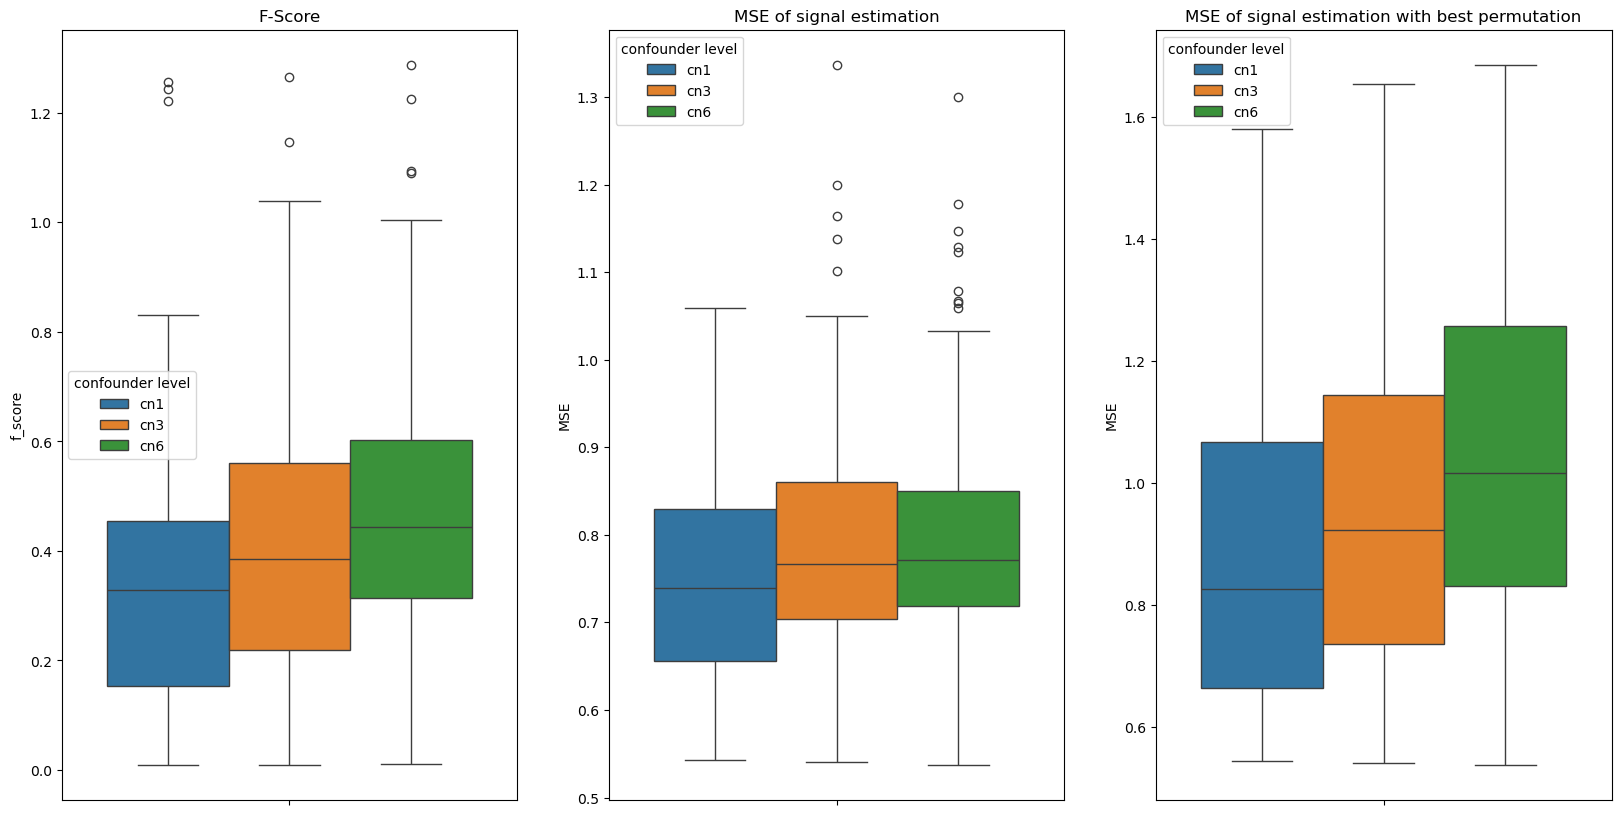

In [33]:
# plot the f_scores in one plot
fig, ax = plt.subplots(1, 3, figsize=(20, 10))
long = fscores.melt(var_name="confounder level", value_name="f_score")
sns.boxplot(data=long, hue="confounder level", y="f_score", ax=ax[0])
ax[0].set_title("F-Score")

long = scores_signals.melt(var_name="confounder level", value_name="MSE")
sns.boxplot(data=long, hue="confounder level", y="MSE", ax=ax[1])
ax[1].set_title("MSE of signal estimation")

long = scores_signals_best_perm.melt(var_name="confounder level", value_name="MSE")
sns.boxplot(data=long, hue="confounder level", y="MSE", ax=ax[2])
ax[2].set_title("MSE of signal estimation with best permutation")



# plot error against level of confoundin

In [36]:
fscores

,cn1,cn3,cn6
0,0.036269,0.19288,0.462289
1,0.08107,0.290073,0.46752
2,0.471326,0.677667,0.828051
3,0.447514,0.523037,0.476763
4,0.17046,0.163433,0.151135
...,...,...,...
95,0.342981,0.416011,0.428562
96,0.062075,0.116893,0.312543
97,0.596928,0.597378,0.656245
98,0.829524,0.952856,1.089892


<Axes: xlabel='level_of_confounding', ylabel='cn6'>

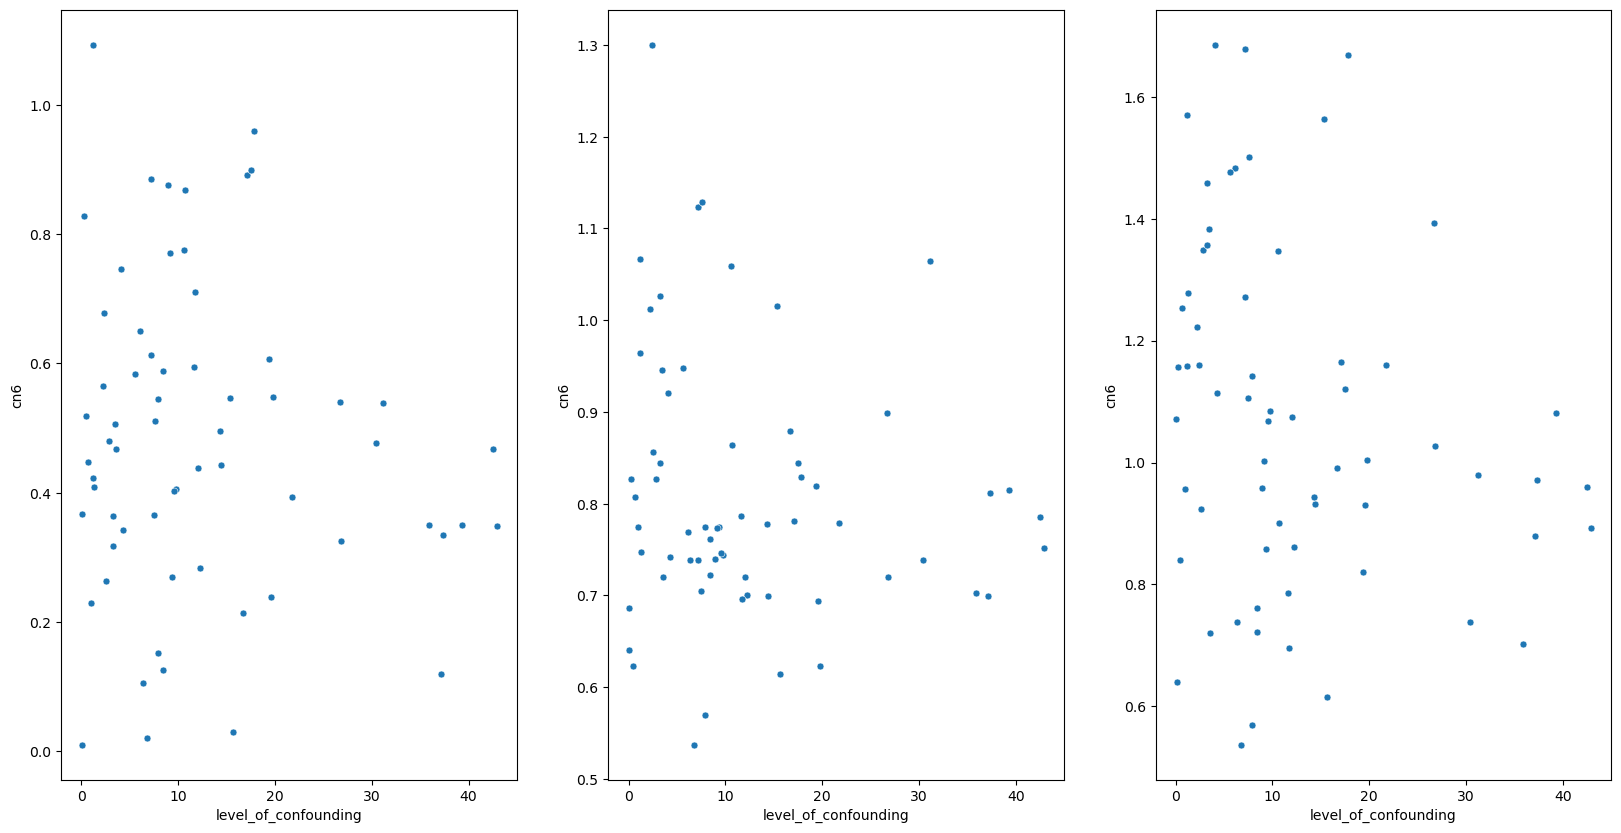

In [53]:
df1  = pd.read_csv(f"../treatment_effect_estimation/treatment_effect_estimations/CausalVarEM_confounder_source_cn_6.csv", header=0, index_col=0)
fig, ax = plt.subplots(1, 3, figsize=(20, 10))
sns.scatterplot(data=df1, x="level_of_confounding", y=fscores["cn6"] ,s = 25, ax=ax[0])
sns.scatterplot(data=df1, x="level_of_confounding", y=scores_signals["cn6"] ,s = 25, ax=ax[1])
sns.scatterplot(data=df1, x="level_of_confounding", y=scores_signals_best_perm["cn6"] ,s = 25, ax=ax[2])


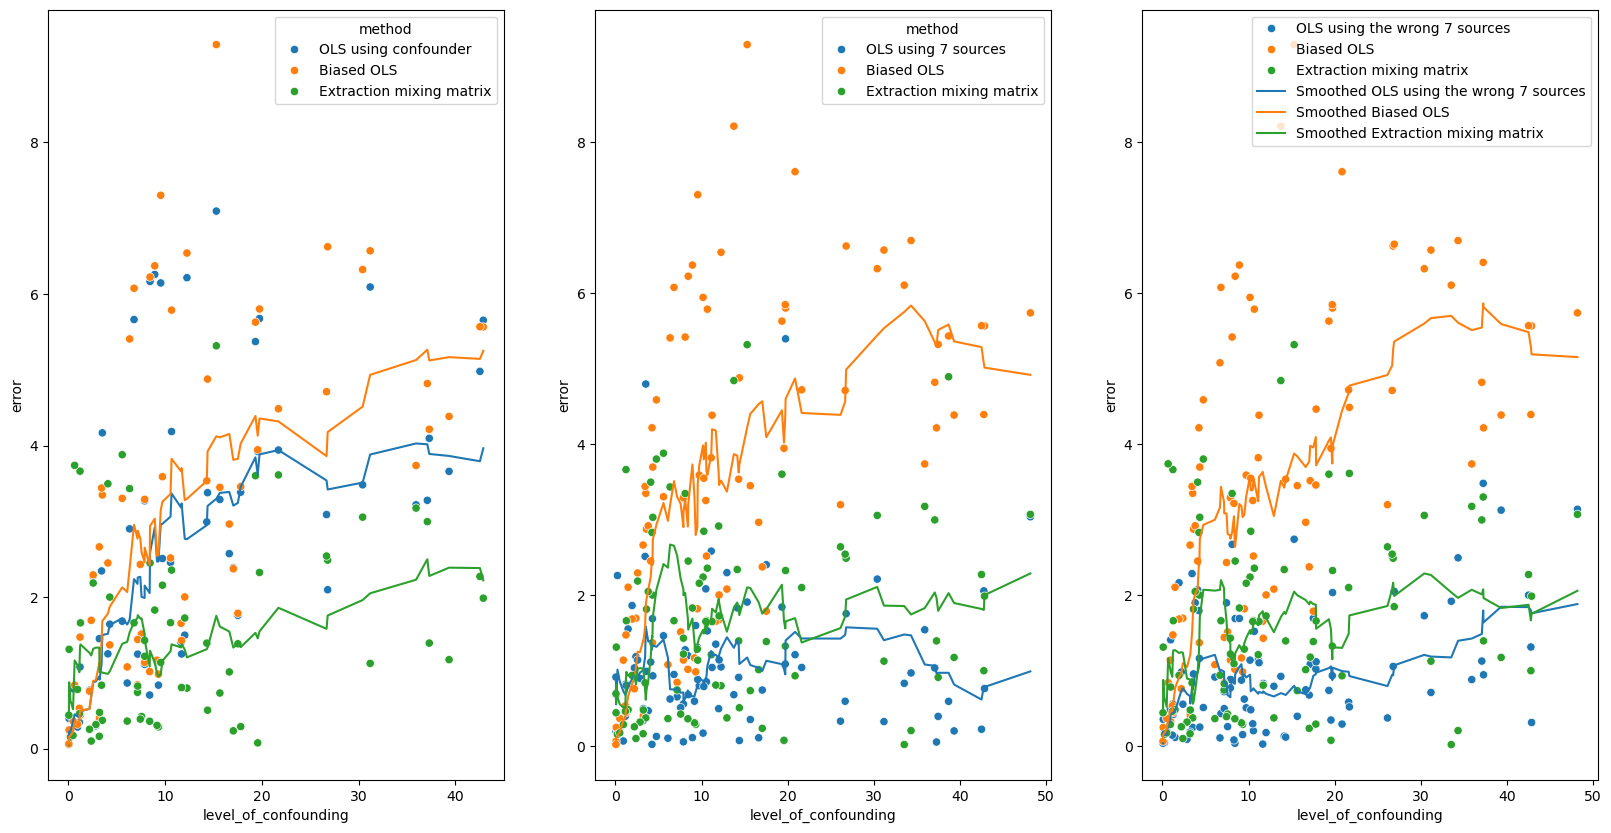

In [74]:

import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

fig, ax = plt.subplots(1, 3, figsize=(20, 10))

def rolling_average(data, x_col, y_col, hue_col, ax, window=10):
    unique_methods = data[hue_col].unique()
    for method in unique_methods:
        subset = data[data[hue_col] == method].sort_values(by=x_col)
        subset["smoothed_error"] = subset[y_col].rolling(window=window, min_periods=1).mean()
        ax.plot(subset[x_col], subset["smoothed_error"], label=f"Smoothed {method}")


df1 = pd.read_csv(f"../treatment_effect_estimation/treatment_effect_estimations/CausalVarEM_confounder_source_cn_6.csv", header=0, index_col=0)
x = df1["level_of_confounding"]
err1, seed = calc_error(df1)
err1 = err1.apply(lambda x: np.abs(x))
err1.columns = ["OLS using confounder", "Biased OLS" ,"Extraction mixing matrix"]
err1 = pd.concat([err1, x], axis=1)
err1 = err1.melt(id_vars="level_of_confounding", var_name="method", value_name="error")

sns.scatterplot(data=err1, x="level_of_confounding", y="error", hue="method", ax=ax[0])
rolling_average(err1, "level_of_confounding", "error", "method", ax[0])

df2 = pd.read_csv(f"../treatment_effect_estimation/treatment_effect_estimations/CausalVarEM_7_sources_cn_6.csv", header=0, index_col=0)
x = df2["level_of_confounding"]
err2, seed = calc_error(df2)
err2 = err2.apply(lambda x: np.abs(x))
err2.columns = ["OLS using 7 sources", "Biased OLS" ,"Extraction mixing matrix"]
err2 = pd.concat([err2, x], axis=1)
err2 = err2.melt(id_vars="level_of_confounding", var_name="method", value_name="error")

sns.scatterplot(data=err2, x="level_of_confounding", y="error", hue="method", ax=ax[1])
rolling_average(err2, "level_of_confounding", "error", "method", ax[1])

df3 = pd.read_csv(f"../treatment_effect_estimation/treatment_effect_estimations/CausalVarEM_7_sources_nonsense_cn_6.csv", header=0, index_col=0)
x = df3["level_of_confounding"]
err3, seed = calc_error(df3)
err3 = err3.apply(lambda x: np.abs(x))
err3.columns = ["OLS using the wrong 7 sources", "Biased OLS" ,"Extraction mixing matrix"]
err3 = pd.concat([err3, x], axis=1)
err3 = err3.melt(id_vars="level_of_confounding", var_name="method", value_name="error")

sns.scatterplot(data=err3, x="level_of_confounding", y="error", hue="method", ax=ax[2])
rolling_average(err3, "level_of_confounding", "error", "method", ax[2])

plt.legend()
plt.show()


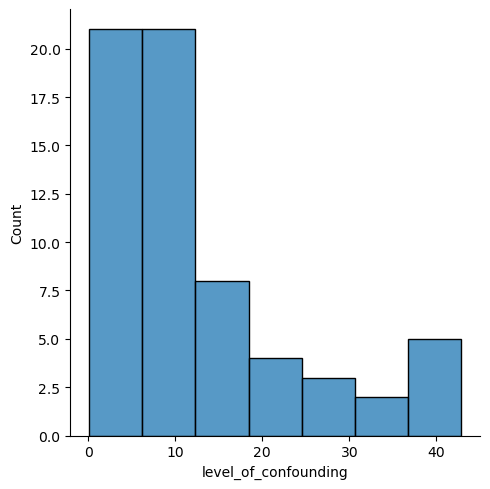

In [55]:
sns.displot(x = x)